# 07: Pose-LRCN — Keypoint Features + LSTM
**Group 11 · COSE474 Deep Learning · Korea University · Spring 2026**

## Overview

This notebook is **notebook 03 (LRCN) with the input modality swapped**: instead of feeding raw pixels through a frozen VGG16, we feed **MediaPipe pose/hand keypoints** through the same frame_fc -> LSTM -> classifier structure.

**Why pose keypoints.** Notebooks 02-06 are all appearance-based (pixels). With only ~12 clips/class, they overfit to skin tone, lighting, and background rather than the sign itself. Pose keypoints discard all appearance and keep only the geometry of the hands and upper body - exactly the information a sign encodes. Keypoint-based methods are the dominant high-accuracy approach for isolated sign language recognition for this reason.

### How this notebook differs from 02 and 03

All three share the signer-independent split, 32 frames, 67 classes, and logging format. They differ in **what each frame is turned into** and **how time is modelled**:

| | 02 - Simple CNN | 03 - Pixel-LRCN | 07 - Pose-LRCN (this) |
|---|---|---|---|
| Input per clip | 1 middle frame | 32 frames | 32 frames |
| Per-frame feature | VGG16 on 1 frame | VGG16 on each frame (25088-d) | MediaPipe keypoints (159-d) |
| Temporal modelling | none (single frame) | LSTM over 32 frames | LSTM over 32 frames |
| What it can capture | static hand pose | appearance + motion | geometry + motion |
| Main weakness | no motion at all | overfits appearance | depends on keypoint quality |
| Trainable params | VGG head only | frozen VGG + LSTM | whole model (~235K) |

**The progression:** 02 proves a single frame is not enough (signs are motion). 03 adds temporal modelling but still sees pixels, so it overfits appearance on a tiny dataset. 07 keeps 03's exact temporal model but replaces the pixel features with pose geometry, testing whether *the input modality* - not the architecture - is what limits accuracy.

### Architecture mapping vs nb03

| Component | nb03 (pixel) | nb07 (pose) |
|---|---|---|
| Per-frame feature | VGG16 -> 25088 | MediaPipe -> 159 |
| frame_fc | Linear(25088,512)+BN | Linear(159,512)+BN |
| LSTM | LSTM(512,64) | **same** |
| Classifier | Linear(64,67) | **same** |
| Recipe | lr 1e-4, batch 8, 50 ep, StepLR | **same** |

Only the per-frame feature source (and therefore frame_fc's input width) changes - keeping this as close to a single-variable change from nb03 as the modality allows.

### Keypoint set: why 53 landmarks (159 features)

Each frame is represented by **53 keypoints x 3 coordinates (x, y, z) = 159 features**:

| Group | Landmarks | Why included |
|---|---|---|
| Left hand | 21 | Hands are the primary articulators - hand-shape and finger position carry most meaning |
| Right hand | 21 | MediaPipe gives a full 21-point skeleton per hand; both hands needed for two-handed signs |
| Upper-body pose | 11 | Locates the hands relative to the body and captures arm movement |

MediaPipe's hand model outputs exactly 21 landmarks per hand (a fixed standard skeleton), so 21+21=42 is not a tunable choice - it is the full hand representation. For the body we take **11 upper-body pose landmarks** rather than all 33, because lower-body points (knees, ankles, feet) never appear in signing clips and would only add noise. The 11 selected: nose, left/right ear, left/right shoulder, left/right elbow, left/right wrist, left/right hip - the head reference, the two arm chains, and the torso anchor. This tells the model where the hands are *relative to the body* (a wrist near the forehead means something different from a wrist near the chest) without diluting the signal with irrelevant lower-body coordinates.

**Why x, y, z (3 coords):** MediaPipe estimates a relative depth z alongside image-plane x, y. Depth helps disambiguate signs where a hand moves toward or away from the body, which looks identical in 2D. 53 x 3 = **159 features per frame**.

**Efficiency:** like nb05, keypoints are extracted **once** and saved to `./pose_features/` as `.npy`. Training then loads pre-saved features -> LSTM only -> loss. MediaPipe never runs during training.

**Baselines:** nb02 Simple CNN = 13.57% · nb03 pixel-LRCN = 14.34% · Shin et al. 2023 = 89.00%

# Imports & Config

In [1]:
# Author: Group 11
# Notebook 07 — Pose-LRCN (MediaPipe keypoints + nb03 LRCN)

import os, csv, random, datetime, glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns

BASE_DIR    = Path('.')
FRAMES_DIR  = BASE_DIR / 'frames'          # JPGs from nb01
POSE_DIR    = BASE_DIR / 'pose_features'   # extracted keypoints (.npy) go here
CKPT_DIR    = BASE_DIR / 'models' / 'checkpoints'
FIGS_DIR    = BASE_DIR / 'results' / 'figures'
LOGS_DIR    = BASE_DIR / 'results' / 'logs'
for d in [POSE_DIR, CKPT_DIR, FIGS_DIR, LOGS_DIR]: d.mkdir(parents=True, exist_ok=True)

# ── Recipe — IDENTICAL to nb03 ───────────────────────────────────────────────
NUM_FRAMES    = 32
BATCH         = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS    = 400
PATIENCE      = 50
LSTM_HIDDEN   = 64
LSTM_LAYERS   = 1
DROPOUT       = 0.4
PROJ_DIM      = 512      # frame_fc output (matches nb03)
RANDOM_SEED   = 42

# ── Keypoint set: both hands (21+21) + upper-body pose (11) ─────────────────
# Upper-body pose landmark indices (MediaPipe Pose 33-point model):
# 0 nose, 7/8 ears, 11/12 shoulders, 13/14 elbows, 15/16 wrists, 23/24 hips
POSE_UPPER = [0, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24]
N_KEYPOINTS = 21 + 21 + len(POSE_UPPER)   # 53
FEAT_DIM    = N_KEYPOINTS * 3             # 159 (x, y, z per keypoint)

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {DEVICE}')
if torch.cuda.is_available(): print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'Keypoints   : {N_KEYPOINTS} (21+21 hands + {len(POSE_UPPER)} pose)')
print(f'Feature dim : {FEAT_DIM} per frame')
print(f'Recipe      : lr={LEARNING_RATE} batch={BATCH} epochs={NUM_EPOCHS} (matches nb03)')

Device      : cuda
GPU         : NVIDIA A100 80GB PCIe MIG 3g.40gb
Keypoints   : 53 (21+21 hands + 11 pose)
Feature dim : 159 per frame
Recipe      : lr=0.001 batch=8 epochs=400 (matches nb03)


# KSL Word Labels

In [2]:
KSL_WORDS = {
     1:'hi',          2:'what',         3:'meat',         4:'bi bim rice',
     5:'glad',        6:'hobby',        7:'me',           8:'movie',
     9:'face',       10:'see',         11:'name',        12:'read',
    13:'thank',      14:'equal',       15:'sorry',       16:'eat',
    17:'fine',       18:'do effort',   19:'next',        20:'age',
    21:'again',      22:'how many',    23:'day',         24:'good, nice',
    25:'when',       26:'we',          27:'subway',      28:'be friendly',
    29:'bus',        30:'ride',        31:'cell phone',  32:'where',
    33:'number',     34:'location',    35:'guide',       36:'responsibility',
    37:'who',        38:'arrive',      39:'family',      40:'time',
    41:'introduction',42:'recieve',    43:'please?',     44:'walk',
    45:'parents',    46:'10 minutes',  47:'sister',      48:'study',
    49:'human',      50:'now',         51:'special',     52:'yesterday',
    53:'education',  54:'test',        55:'end',         56:'you',
    57:'worried_about',58:'marry',     59:'effort',      60:'no',
    61:'sweat',      62:'yet',         63:'finally',     64:'born',
    65:'success',    66:'favor',       67:'Seoul',       68:'dinner',
    69:'experience', 70:'invite',      71:'food',        72:'want',
    73:'visit',      74:'one hour',    75:'far',         76:'good',
    77:'care',
}
print(f'KSL words: {len(KSL_WORDS)}')

KSL words: 77


# Phase 1: Extract Keypoints (run once)

Runs MediaPipe Holistic over the 32 JPGs of each clip in `./frames/`, extracts a **159-dim keypoint vector per frame** (53 landmarks x 3), and saves `(32, 159)` arrays to `./pose_features/{clip}.npy`.

Missing detections (e.g. a hand off-screen) are filled with zeros. Keypoints are centred on the nose and scaled by shoulder width so the model is translation- and scale-invariant - the sign means the same regardless of where the signer stands.

**Requires** `mediapipe` with the legacy Solutions API (`pip install mediapipe`, Python 3.9-3.11). Re-running skips clips already extracted.

**Runtime:** ~1-2 min per 100 clips on CPU. ~15-25 min for all 1,229 clips. One-time cost.

In [3]:
# ── Install system libs + a mediapipe version with the legacy Solutions API ──
# MediaPipe (via OpenCV) needs libGL; newest mediapipe builds dropped solutions.holistic,
# so we pin to 0.10.9 which still ships it and runs on Python 3.10.
import subprocess, importlib, sys

def _have_holistic():
    try:
        import mediapipe as mp
        return hasattr(mp, 'solutions') and hasattr(mp.solutions, 'holistic')
    except Exception:
        return False

if not _have_holistic():
    # 1) system libraries for OpenCV
    subprocess.run(['apt-get', 'update', '-qq'], check=False)
    subprocess.run(['apt-get', 'install', '-y', '-qq', 'libgl1', 'libglib2.0-0'], check=False)
    # 2) mediapipe version that includes solutions.holistic
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet',
                    'mediapipe==0.10.9'], check=True)
    # drop any partially-loaded mediapipe/cv2 modules so the reinstall takes effect
    for m in [k for k in list(sys.modules) if k.startswith(('mediapipe', 'cv2'))]:
        del sys.modules[m]

import mediapipe as mp
if not (hasattr(mp, 'solutions') and hasattr(mp.solutions, 'holistic')):
    raise RuntimeError(
        'mediapipe.solutions.holistic still unavailable. '
        'Restart the kernel (Kernel -> Restart) and run this cell again.'
    )
mp_holistic = mp.solutions.holistic
print(f'mediapipe {mp.__version__} ready (solutions.holistic available)')


def normalise(kp_xyz, pose_pts):
    """
    Centre on nose, scale by shoulder width. kp_xyz: (N,3). pose_pts: raw pose landmark list or None.
    Falls back to raw coords if pose unavailable.
    """
    if pose_pts is None:
        return kp_xyz
    nose = np.array([pose_pts[0].x, pose_pts[0].y, pose_pts[0].z], dtype=np.float32)
    lsh  = np.array([pose_pts[11].x, pose_pts[11].y, pose_pts[11].z], dtype=np.float32)
    rsh  = np.array([pose_pts[12].x, pose_pts[12].y, pose_pts[12].z], dtype=np.float32)
    shoulder_w = np.linalg.norm(lsh - rsh) + 1e-6
    out = (kp_xyz - nose) / shoulder_w
    return out

def extract_clip_keypoints(clip_dir, holistic):
    """Return (NUM_FRAMES, FEAT_DIM) keypoint array for one clip."""
    frame_files = sorted(os.listdir(clip_dir))[:NUM_FRAMES]
    frames_kp = []
    for fname in frame_files:
        img = np.array(Image.open(os.path.join(clip_dir, fname)).convert('RGB'))
        res = holistic.process(img)

        def hand(lms):
            if lms is None: return np.zeros((21, 3), dtype=np.float32)
            return np.array([[p.x, p.y, p.z] for p in lms.landmark], dtype=np.float32)
        def pose_sel(lms):
            if lms is None: return np.zeros((len(POSE_UPPER), 3), dtype=np.float32)
            pts = lms.landmark
            return np.array([[pts[i].x, pts[i].y, pts[i].z] for i in POSE_UPPER], dtype=np.float32)

        lh = hand(res.left_hand_landmarks)
        rh = hand(res.right_hand_landmarks)
        po = pose_sel(res.pose_landmarks)
        all_kp = np.concatenate([lh, rh, po], axis=0)
        all_kp = normalise(all_kp, res.pose_landmarks.landmark if res.pose_landmarks else None)
        frames_kp.append(all_kp.flatten())

    arr = np.array(frames_kp, dtype=np.float32)
    if len(arr) < NUM_FRAMES:
        pad = np.repeat(arr[-1:], NUM_FRAMES - len(arr), axis=0)
        arr = np.concatenate([arr, pad], axis=0)
    return arr[:NUM_FRAMES]

print('Keypoint extraction functions defined.')

mediapipe 0.10.9 ready (solutions.holistic available)
Keypoint extraction functions defined.


In [4]:
import os
import numpy as np
from concurrent.futures import ProcessPoolExecutor
import mediapipe as mp

# Reduce MediaPipe logging noise
os.environ["GLOG_minloglevel"] = "2"

# Global Holistic instance (one per worker process)
HOLISTIC = None


def init_worker():
    global HOLISTIC

    HOLISTIC = mp.solutions.holistic.Holistic(
        static_image_mode=True,
        model_complexity=1,
        min_detection_confidence=0.5
    )


def process_single_clip(clip_dir):
    global HOLISTIC

    out_path = POSE_DIR / f"{clip_dir.name}.npy"

    if out_path.exists():
        return "skipped"

    try:
        arr = extract_clip_keypoints(
            str(clip_dir),
            HOLISTIC
        )

        np.save(str(out_path), arr)

        return "done"

    except Exception as e:
        return f"failed: {clip_dir.name} -> {e}"


# --------------------------------------------------
# Gather clip folders
# --------------------------------------------------

clip_dirs = sorted([
    FRAMES_DIR / d
    for d in os.listdir(FRAMES_DIR)
    if os.path.isdir(FRAMES_DIR / d)
])

total = len(clip_dirs)

print(f"Total clips to process: {total}")

# --------------------------------------------------
# Parallel processing
# --------------------------------------------------

MAX_WORKERS = 4

done_cnt = 0
skipped_cnt = 0
failed = []

print(f"Starting parallel extraction using {MAX_WORKERS} workers...")

with ProcessPoolExecutor(
    max_workers=MAX_WORKERS,
    initializer=init_worker
) as executor:

    for idx, result in enumerate(
        executor.map(process_single_clip, clip_dirs),
        start=1
    ):

        if result == "done":
            done_cnt += 1

        elif result == "skipped":
            skipped_cnt += 1

        else:
            failed.append(result)

        # Progress update every 50 clips
        if idx % 50 == 0 or idx == total:
            print(
                f"[{idx}/{total}] "
                f"Done={done_cnt} "
                f"Skipped={skipped_cnt} "
                f"Failed={len(failed)}"
            )

# --------------------------------------------------
# Summary
# --------------------------------------------------

print("\nParallel Extraction Finished")
print(f"Extracted : {done_cnt}")
print(f"Skipped   : {skipped_cnt}")
print(f"Failed    : {len(failed)}")

if failed:
    print("\nFirst failures:")
    for msg in failed[:10]:
        print(msg)

Total clips to process: 1229
Starting parallel extraction using 4 workers...
[50/1229] Done=0 Skipped=50 Failed=0
[100/1229] Done=0 Skipped=100 Failed=0
[150/1229] Done=0 Skipped=150 Failed=0
[200/1229] Done=0 Skipped=200 Failed=0
[250/1229] Done=0 Skipped=250 Failed=0
[300/1229] Done=0 Skipped=300 Failed=0
[350/1229] Done=0 Skipped=350 Failed=0
[400/1229] Done=0 Skipped=400 Failed=0
[450/1229] Done=0 Skipped=450 Failed=0
[500/1229] Done=0 Skipped=500 Failed=0
[550/1229] Done=0 Skipped=550 Failed=0
[600/1229] Done=0 Skipped=600 Failed=0
[650/1229] Done=0 Skipped=650 Failed=0
[700/1229] Done=0 Skipped=700 Failed=0
[750/1229] Done=0 Skipped=750 Failed=0
[800/1229] Done=0 Skipped=800 Failed=0


E0000 00:00:1780825236.063490   58568 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1780825236.063565   58568 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1780825236.063574   58568 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1780825236.063582   58568 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1780825236.063590   58568 gl_context.cc:408] INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:303) successeglMakeCurrent() returned error 0x3008;  (entering GL context)
E0000 00:00:1780825236.06

[850/1229] Done=0 Skipped=850 Failed=0
[900/1229] Done=0 Skipped=900 Failed=0
[950/1229] Done=0 Skipped=950 Failed=0
[1000/1229] Done=0 Skipped=1000 Failed=0
[1050/1229] Done=0 Skipped=1050 Failed=0
[1100/1229] Done=0 Skipped=1100 Failed=0
[1150/1229] Done=0 Skipped=1150 Failed=0
[1200/1229] Done=0 Skipped=1200 Failed=0
[1229/1229] Done=0 Skipped=1229 Failed=0

Parallel Extraction Finished
Extracted : 0
Skipped   : 1229
Failed    : 0


# Phase 2: Pose Dataset

Loads pre-saved `.npy` keypoint arrays — fast, no MediaPipe at train time. This mirrors nb05's pattern: each batch loads pre-extracted features straight into the LSTM.

In [5]:
class PoseDataset(Dataset):
    """Loads pre-saved (NUM_FRAMES, FEAT_DIM) keypoint arrays."""
    def __init__(self, npy_paths, label_map):
        self.paths = npy_paths
        self.label_map = label_map
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        # filename: {signer}_{class}.npy
        class_id = int(os.path.basename(p).split('_')[1].replace('.npy',''))
        label = self.label_map[class_id]
        feats = np.load(p)                      # (NUM_FRAMES, FEAT_DIM)
        return torch.from_numpy(feats).float(), label

print('PoseDataset defined.')

PoseDataset defined.


# Split + Label Remapping (signer-independent, same as nb03)

In [6]:
TRAIN_SIGNERS = {f'{i:02d}' for i in range(16)}
VAL_SIGNERS   = {f'{i:02d}' for i in range(16, 20)}

all_npy = sorted(glob.glob(str(POSE_DIR / '*.npy')))
print(f'Keypoint files: {len(all_npy)}')

present_class_ids  = sorted({int(os.path.basename(p).split('_')[1].replace('.npy',''))
                             for p in all_npy})
LABEL_MAP          = {cid: i for i, cid in enumerate(present_class_ids)}
NUM_CLASSES_ACTUAL = len(present_class_ids)
INDEX_TO_WORD      = [KSL_WORDS[cid] for cid in present_class_ids]

train_npy = [p for p in all_npy if os.path.basename(p).split('_')[0] in TRAIN_SIGNERS]
val_npy   = [p for p in all_npy if os.path.basename(p).split('_')[0] in VAL_SIGNERS]

print(f'Classes : {NUM_CLASSES_ACTUAL}  |  Train : {len(train_npy)}  Val : {len(val_npy)}')

train_ds = PoseDataset(train_npy, LABEL_MAP)
val_ds   = PoseDataset(val_npy,   LABEL_MAP)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=4, pin_memory=True)

feats, lbl = train_ds[0]
print(f'Sample feature shape: {feats.shape}  (expect ({NUM_FRAMES}, {FEAT_DIM}))')

Keypoint files: 1229
Classes : 67  |  Train : 971  Val : 258
Sample feature shape: torch.Size([32, 159])  (expect (32, 159))


# Phase 3: Pose-LRCN Model

Same LRCN as nb03 — `frame_fc → LSTM → last timestep → classifier`. The only structural difference is `frame_fc`'s input dimension: 159 (keypoints) instead of 25088 (VGG features). No frozen backbone, so the whole model is trainable and tiny (~235K params vs nb03's frozen 14M VGG).

In [7]:
# class PoseLRCN(nn.Module):
#     """
#     nb03 LRCN with keypoint input.
#     frame_fc projects FEAT_DIM keypoints -> PROJ_DIM, then LSTM over time,
#     last hidden state -> classifier. No VGG backbone.
#     """
#     def __init__(self, feat_dim=FEAT_DIM, num_classes=None, proj_dim=PROJ_DIM,
#                  lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS, dropout=DROPOUT):
#         super().__init__()
#         if num_classes is None: num_classes = NUM_CLASSES_ACTUAL
#         self.frame_fc = nn.Sequential(
#             nn.Linear(feat_dim, proj_dim),
#             nn.BatchNorm1d(proj_dim),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#         )
#         self.lstm = nn.LSTM(
#             input_size=proj_dim, hidden_size=lstm_hidden,
#             num_layers=lstm_layers, batch_first=True,
#         )
#         self.classifier = nn.Sequential(
#             nn.Dropout(dropout),
#             nn.Linear(lstm_hidden, num_classes),
#         )

#     def forward(self, x):
#         B, T, F = x.shape
#         x = x.view(B * T, F)
#         x = self.frame_fc(x)
#         x = x.view(B, T, -1)
#         out, (h_n, _) = self.lstm(x)
#         last = out[:, -1, :]
#         return self.classifier(last)

# model = PoseLRCN().to(DEVICE)
# trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f'Output classes   : {NUM_CLASSES_ACTUAL}')
# print(f'Trainable params : {trainable:,}  (entire model — no frozen backbone)')
class PoseLRCN(nn.Module):
    """
    Pose keypoints -> FC projection -> BiLSTM -> classifier
    """
    def __init__(self, feat_dim=FEAT_DIM, num_classes=None, proj_dim=PROJ_DIM,
                 dropout=DROPOUT):
        super().__init__()
        if num_classes is None:
            num_classes = NUM_CLASSES_ACTUAL
        hidden_size = 128
        self.frame_fc = nn.Sequential(
            nn.Linear(feat_dim, proj_dim),
            nn.BatchNorm1d(proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=proj_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, num_classes)
        )

    def forward(self, x):
        B, T, F = x.shape
        x = x.view(B * T, F)
        x = self.frame_fc(x)
        x = x.view(B, T, -1)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.classifier(last)

model = PoseLRCN().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Output classes   : {NUM_CLASSES_ACTUAL}')
print(f'Trainable params : {trainable:,}')

Output classes   : 67
Trainable params : 1,152,835


# Training Setup (nb03 recipe)

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
print(f'Loss      : CrossEntropyLoss (label_smoothing=0.1)')
print(f'Optimizer : Adam (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'Scheduler : CosineAnnealing(optimizer, T_max=50)')
print(f'Epochs    : {NUM_EPOCHS}   Patience : {PATIENCE}')

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : Adam (lr=0.001, wd=0.0001)
Scheduler : CosineAnnealing(optimizer, T_max=50)
Epochs    : 400   Patience : 50


# Train / Val Functions

In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0., 0, 0
    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(feats)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_sum += loss.item()
        correct += logits.argmax(1).eq(labels).sum().item()
        total += labels.size(0)
    return loss_sum/len(loader), 100.*correct/total

def val_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for feats, labels in loader:
            feats, labels = feats.to(device), labels.to(device)
            logits = model(feats)
            loss = criterion(logits, labels)
            loss_sum += loss.item()
            p = logits.argmax(1)
            correct += p.eq(labels).sum().item()
            total += labels.size(0)
            preds_all.extend(p.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    return loss_sum/len(loader), 100.*correct/total, preds_all, labels_all

## Run Training

In [10]:
CKPT_PATH = str(CKPT_DIR / 'pose_lrcn.pth')
history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc']}
best_val, patience_cnt = 0., 0
best_preds, best_labels = [], []

print(f"{'Epoch':>5} {'Tr Loss':>9} {'Tr Acc':>8} {'Vl Loss':>9} {'Vl Acc':>8}")
print('-'*48)

for epoch in range(1, NUM_EPOCHS+1):
    tr_l, tr_a = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_l, vl_a, vl_p, vl_lb = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()
    for k, v in zip(['train_loss','train_acc','val_loss','val_acc'],[tr_l,tr_a,vl_l,vl_a]):
        history[k].append(v)
    mark = ' <-- best' if vl_a > best_val else ''
    print(f'{epoch:>5} {tr_l:>9.4f} {tr_a:>7.2f}% {vl_l:>9.4f} {vl_a:>7.2f}%{mark}')
    if vl_a > best_val:
        best_val, best_preds, best_labels, patience_cnt = vl_a, vl_p, vl_lb, 0
        torch.save(model.state_dict(), CKPT_PATH)
    else: patience_cnt += 1
    if patience_cnt >= PATIENCE: print(f'\nEarly stop at epoch {epoch}'); break

print(f'\nBest val acc : {best_val:.2f}%')
print(f'nb03 pixel-LRCN : 14.34%  ->  delta: {best_val-14.34:+.2f} pp')

Epoch   Tr Loss   Tr Acc   Vl Loss   Vl Acc
------------------------------------------------
    1    4.2214    1.24%    4.1749    3.49% <-- best
    2    4.0629    2.57%    4.0870    3.88% <-- best
    3    3.9533    2.47%    4.0803    2.71%
    4    3.9052    3.91%    4.0922    1.94%
    5    3.8753    3.19%    4.0569    2.33%
    6    3.8228    5.25%    4.1073    3.10%
    7    3.7838    5.56%    4.0484    4.65% <-- best
    8    3.7749    5.25%    4.0436    3.10%
    9    3.7484    6.49%    4.0603    3.10%
   10    3.7092    7.31%    4.0663    3.49%
   11    3.6135    9.17%    4.0174    5.04% <-- best
   12    3.5961    8.03%    3.9986    3.49%
   13    3.5474    9.06%    4.0052    5.43% <-- best
   14    3.4731   10.81%    3.9152    5.81% <-- best
   15    3.4074   12.26%    3.9983    4.65%
   16    3.3336   15.14%    3.9041    6.59% <-- best
   17    3.3055   17.10%    3.9691    5.81%
   18    3.2590   14.42%    3.8460   10.47% <-- best
   19    3.2021   17.20%    3.8170    9.69%

# Results — Curves

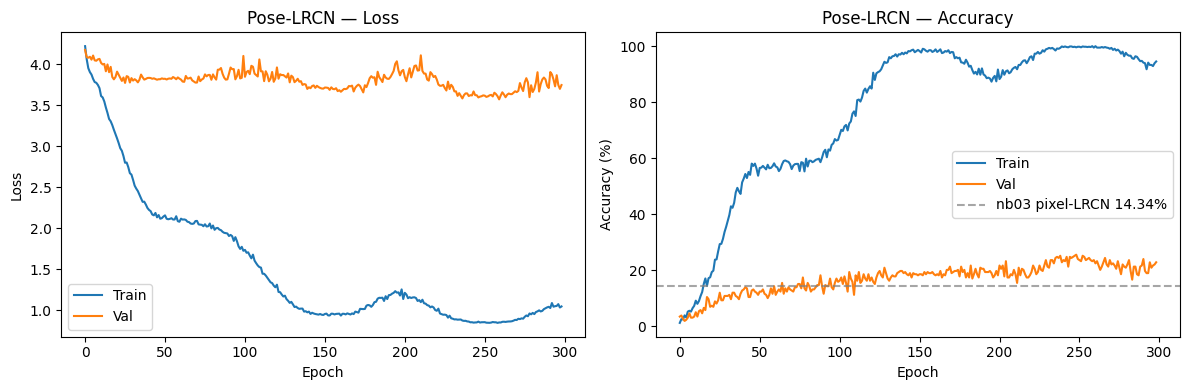

Saved: results/figures/07_pose_lrcn_curves.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train'); ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Pose-LRCN — Loss'); ax1.legend()
ax2.plot(history['train_acc'], label='Train'); ax2.plot(history['val_acc'], label='Val')
ax2.axhline(14.34, color='grey', ls='--', alpha=0.7, label='nb03 pixel-LRCN 14.34%')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.set_title('Pose-LRCN — Accuracy'); ax2.legend()
plt.tight_layout()
path = str(FIGS_DIR / '07_pose_lrcn_curves.png')
plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show(); print(f'Saved: {path}')

# Results — Confusion Matrix

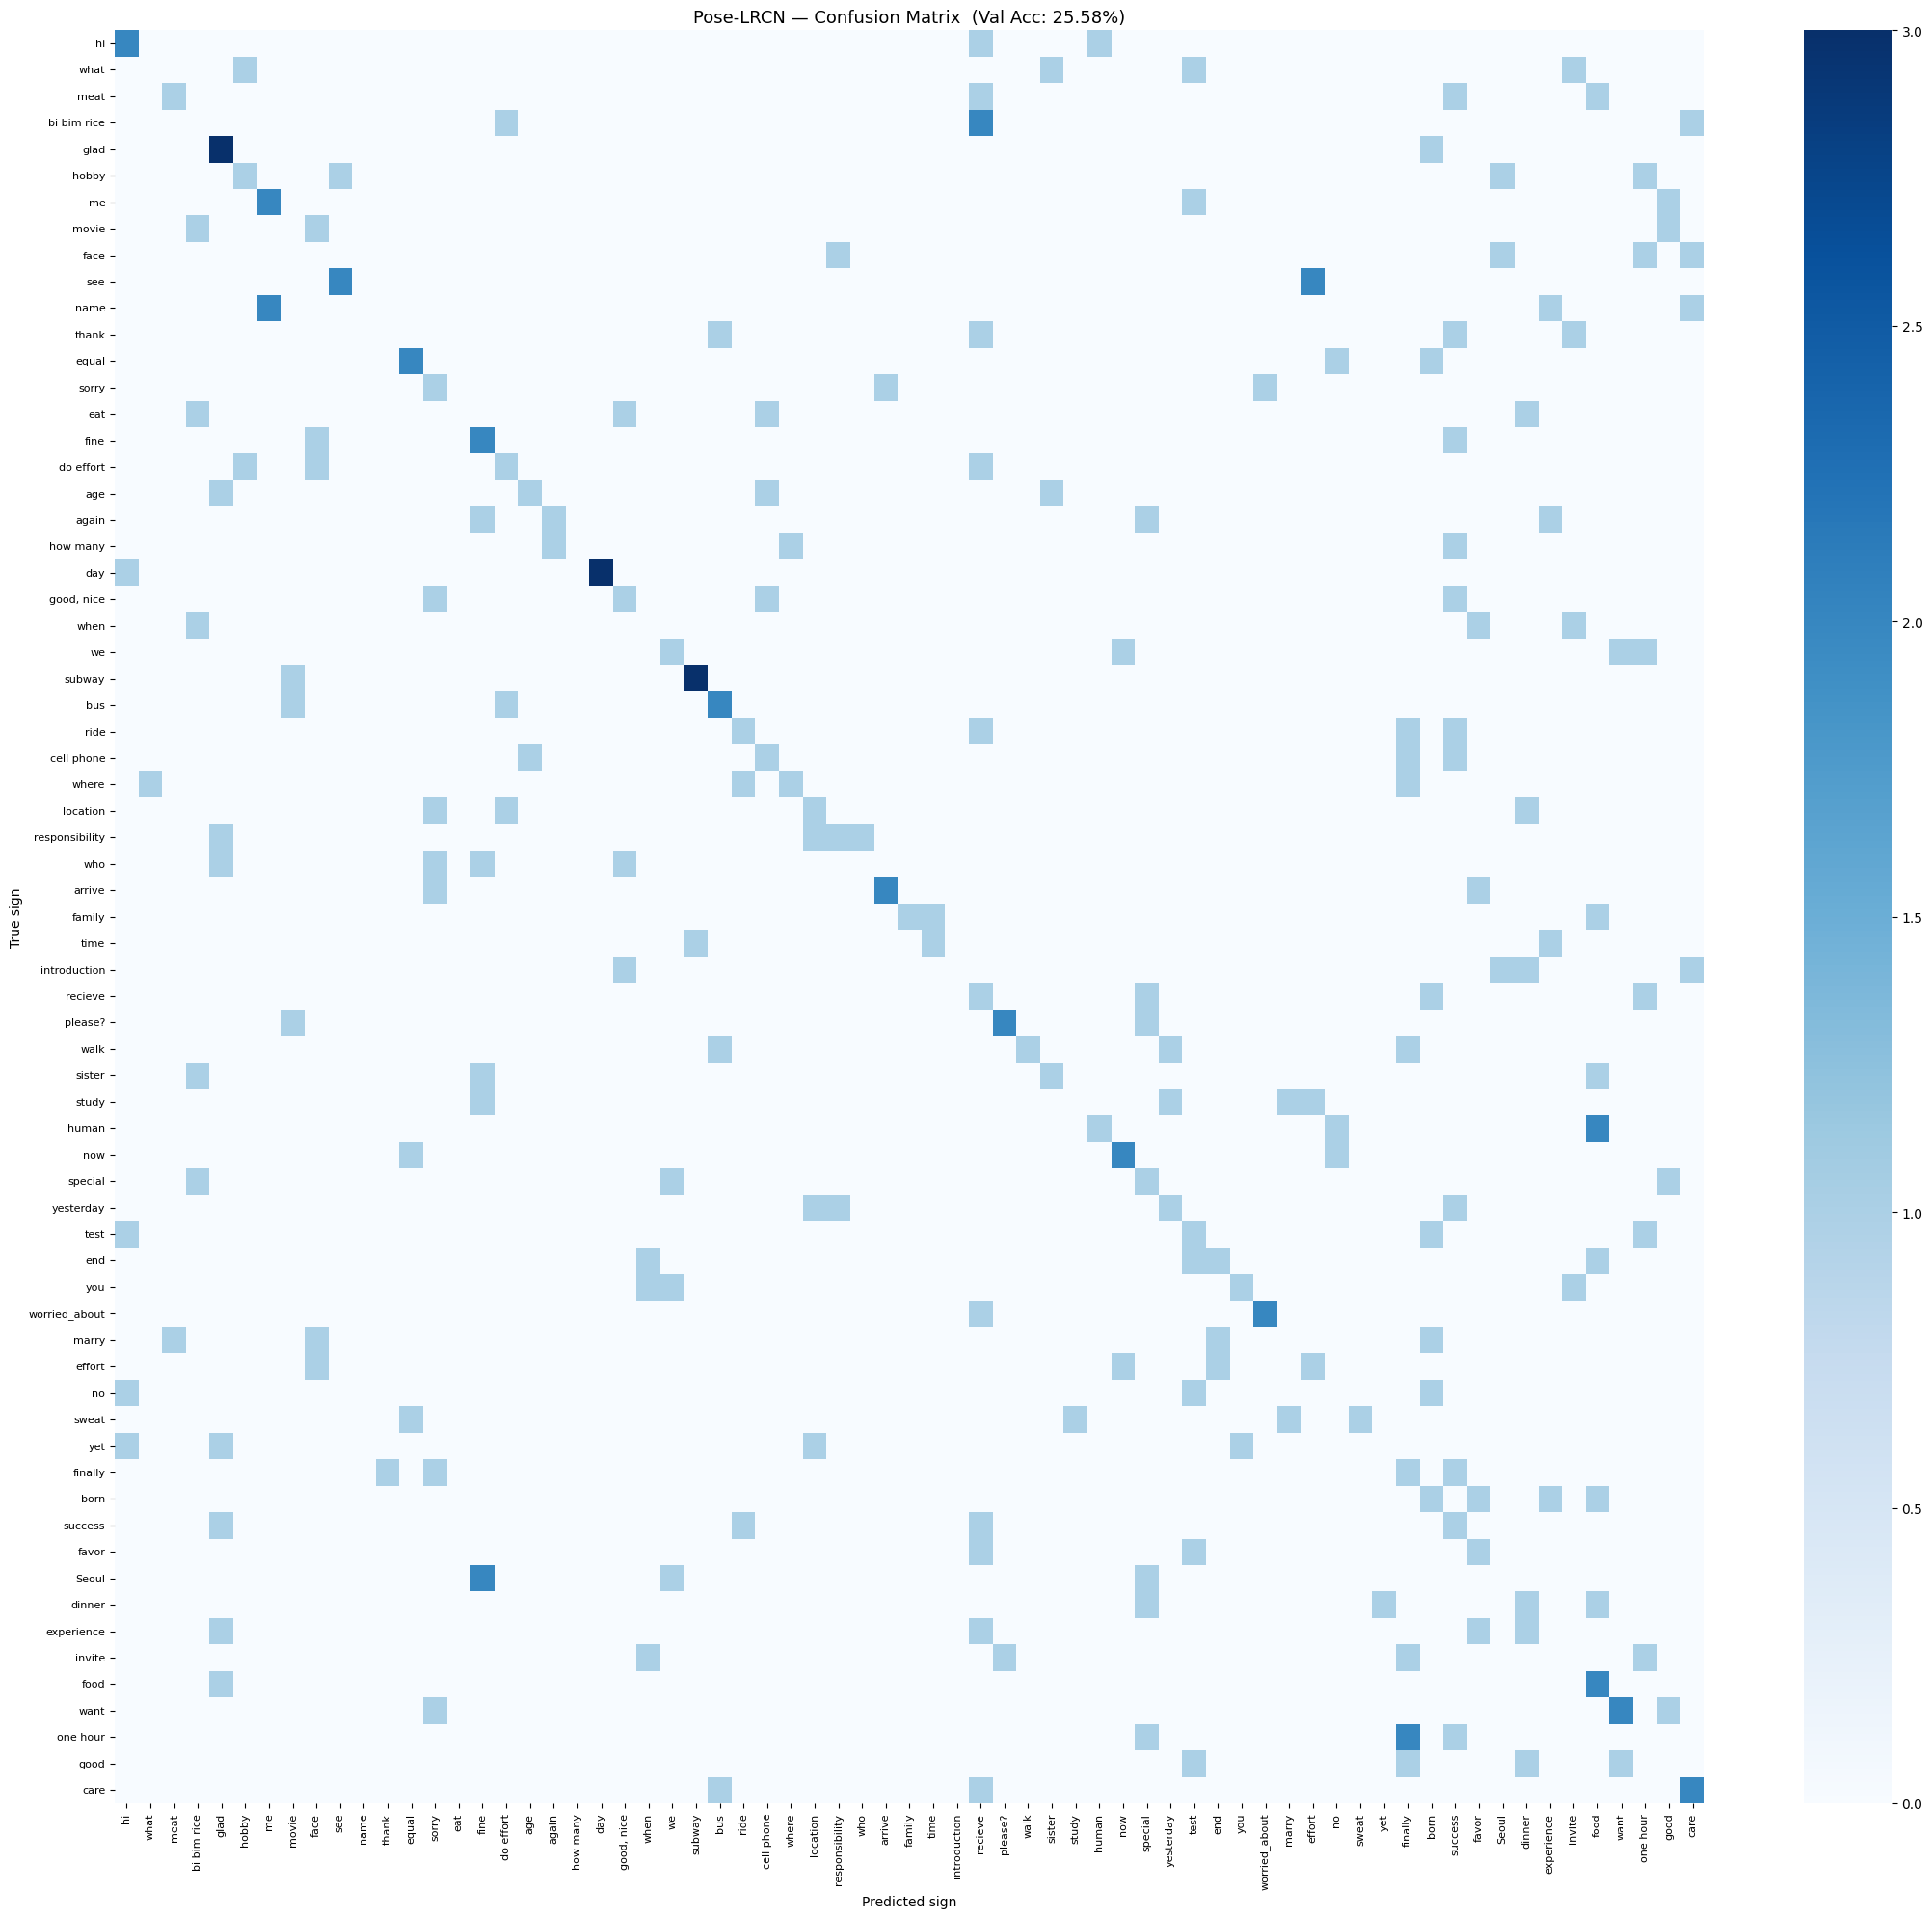

In [12]:
cm = confusion_matrix(best_labels, best_preds, labels=list(range(NUM_CLASSES_ACTUAL)))
fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
            xticklabels=INDEX_TO_WORD, yticklabels=INDEX_TO_WORD)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=8)
ax.set_title(f'Pose-LRCN — Confusion Matrix  (Val Acc: {best_val:.2f}%)', fontsize=13)
ax.set_ylabel('True sign'); ax.set_xlabel('Predicted sign')
plt.tight_layout()
path = str(FIGS_DIR / '07_pose_lrcn_confusion.png')
plt.savefig(path, dpi=150, bbox_inches='tight'); plt.show()

# Log Results

In [13]:
row = {
    'experiment'      : '07_pose_lrcn',
    'date'            : datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model'           : 'Pose-LRCN (MediaPipe keypoints + LSTM)',
    'modality'        : 'pose_keypoints',
    'temporal_modeling': True,
    'augmentation'    : False,
    'transfer'        : False,
    'n_keypoints'     : N_KEYPOINTS,
    'feat_dim'        : FEAT_DIM,
    'train_signers'   : '00-15',
    'val_signers'     : '16-19',
    'num_classes'     : NUM_CLASSES_ACTUAL,
    'num_frames'      : NUM_FRAMES,
    'batch'           : BATCH,
    'lr'              : LEARNING_RATE,
    'lstm_hidden'     : LSTM_HIDDEN,
    'best_val_acc'    : round(best_val, 2),
    'delta_vs_nb03'   : round(best_val - 14.34, 2),
    'epochs_run'      : len(history['val_acc']),
    'notes'           : 'nb03 LRCN with pose-keypoint input instead of VGG pixels. Signer-independent.'
}
log_path = str(LOGS_DIR / '07_pose_lrcn_log.csv')
write_header = not os.path.exists(log_path)
with open(log_path, 'a', newline='') as f:
    w = csv.DictWriter(f, fieldnames=row.keys())
    if write_header: w.writeheader()
    w.writerow(row)
print('Logged:')
for k,v in row.items(): print(f'  {k}: {v}')

Logged:
  experiment: 07_pose_lrcn
  date: 2026-06-07 09:44
  model: Pose-LRCN (MediaPipe keypoints + LSTM)
  modality: pose_keypoints
  temporal_modeling: True
  augmentation: False
  transfer: False
  n_keypoints: 53
  feat_dim: 159
  train_signers: 00-15
  val_signers: 16-19
  num_classes: 67
  num_frames: 32
  batch: 8
  lr: 0.001
  lstm_hidden: 64
  best_val_acc: 25.58
  delta_vs_nb03: 11.24
  epochs_run: 299
  notes: nb03 LRCN with pose-keypoint input instead of VGG pixels. Signer-independent.
